## Recourse

### Restrict to models with high TPR -- not helpful, as it directly changes the measure we're reporting

In [ ]:
tp_rates = {}
# load predictions and measured accuracies
for task in TASKS:
    task_df = df[(df["task"] == task)]

    # available models
    models = task_df["model"].unique().tolist()
    models.sort(key=lambda m: get_model_size_B(m) + int(is_instruction_tuned(m)))
    tp_rates[task] = {}
    for m in models:
        data_m = task_df[task_df["model"] == m]
        assert (
            data_m.shape[0] == 1
        ), f"Expected 1 row for model {m} but found {data_m.shape[0]}"
        tp_rates[task][m] = get_metric(
            data_m.iloc[0]["eval_results_path"], metric="tpr"
        )

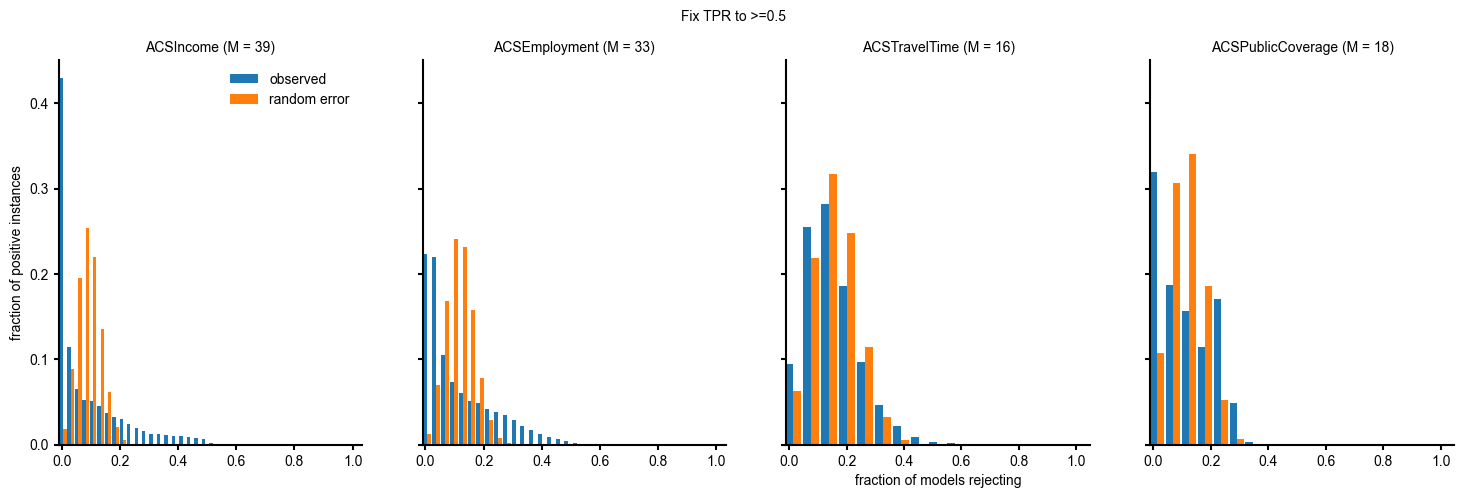

In [ ]:
tp_threshold = 0.5
tp_rates_above_thresh = {
    task: {k: v for k, v in tp_rates[task].items() if v >= tp_threshold}
    for task in TASKS
}
predictions_filtered = {
    task: pred.filter(items=tp_rates_above_thresh[task].keys())
    for task, pred in predictions.items()
}
fn_rates_filtered = {
    task: {
        model: v
        for model, v in fn_rates[task].items()
        if model in tp_rates_above_thresh[task].keys()
    }
    for task in TASKS
}

plot_model_agreement_all_tasks(
    tasks=TASKS,
    predictions=predictions_filtered,
    baseline_rates=fn_rates_filtered,
    data=data,
    restrict_only_pos_instances=True,
    title=f"Fix TPR to >={tp_threshold}",
    plot_cumulative=False,
    save_path=None,
)

### Restrict to models with fixed positive prediction rate

In [ ]:
pos_pred_rates = {}  # pred_pos/total
pos_pred_to_pos_ratio = {}  # pred_pos/pos
# load predictions and measured accuracies
for task in TASKS:
    task_df = df[(df["task"] == task)]

    # available models
    models = task_df["model"].unique().tolist()
    models.sort(key=lambda m: get_model_size_B(m) + int(is_instruction_tuned(m)))
    pos_pred_rates[task] = {}
    pos_pred_to_pos_ratio[task] = {}
    for m in models:
        data_m = task_df[task_df["model"] == m]
        assert (
            data_m.shape[0] == 1
        ), f"Expected 1 row for model {m} but found {data_m.shape[0]}"
        pos_pred_rates[task][m] = get_metric(
            data_m.iloc[0]["eval_results_path"], metric="ppr"
        )
        pos_pred_to_pos_ratio[task][m] = get_metric(
            data_m.iloc[0]["eval_results_path"], metric="num_pred_positives"
        ) / get_metric(data_m.iloc[0]["eval_results_path"], metric="num_positives")

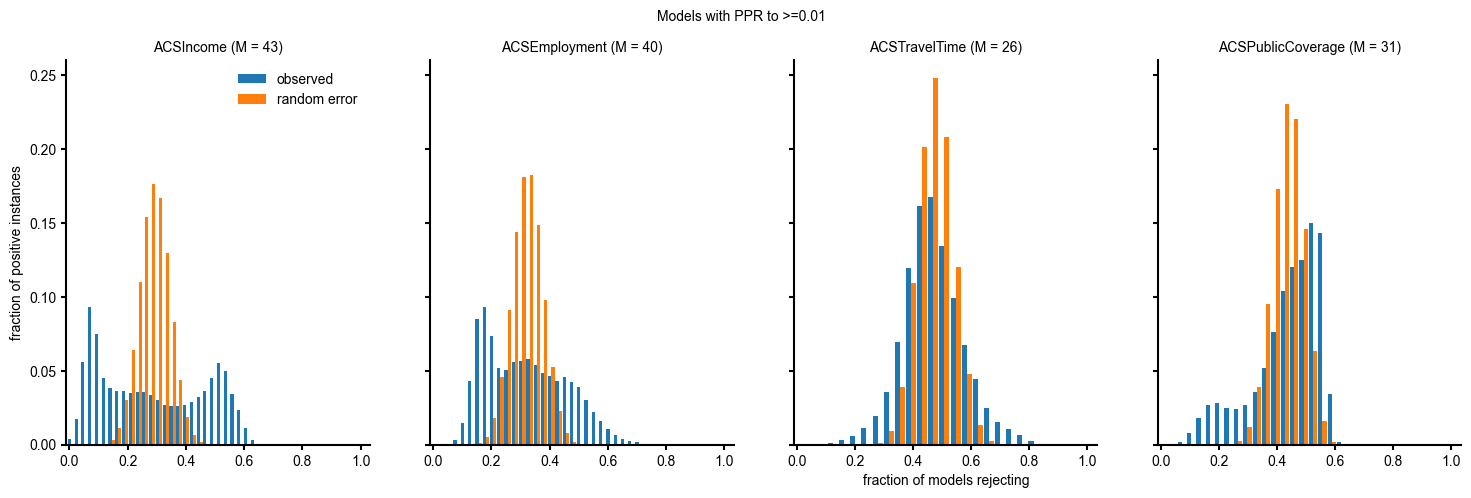

In [ ]:
ppr_threshold = 0.01

npr_below_thresh = {
    task: {k: 1 - v for k, v in pos_pred_rates[task].items() if v >= ppr_threshold}
    for task in TASKS
}
predictions_filtered = {
    task: pred.filter(items=npr_below_thresh[task].keys())
    for task, pred in predictions.items()
}

plot_model_agreement_all_tasks(
    tasks=TASKS,
    predictions=predictions_filtered,
    baseline_rates=npr_below_thresh,
    data=data,
    restrict_only_pos_instances=False,
    title=f"Models with PPR to >={ppr_threshold}",
    plot_cumulative=False,
    save_path=None,
)

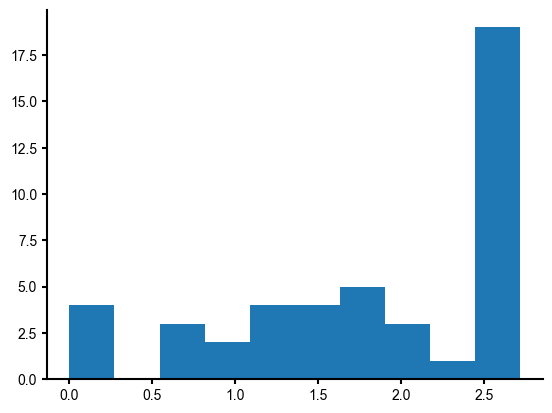

In [ ]:
plt.hist(pos_pred_to_pos_ratio["ACSIncome"].values())
plt.show()
## ratio often larger than 1, i.e. "more resources than positive instances" -- cannot use it as probability
## cap to 1? then what does the expected rejection probability even mean?

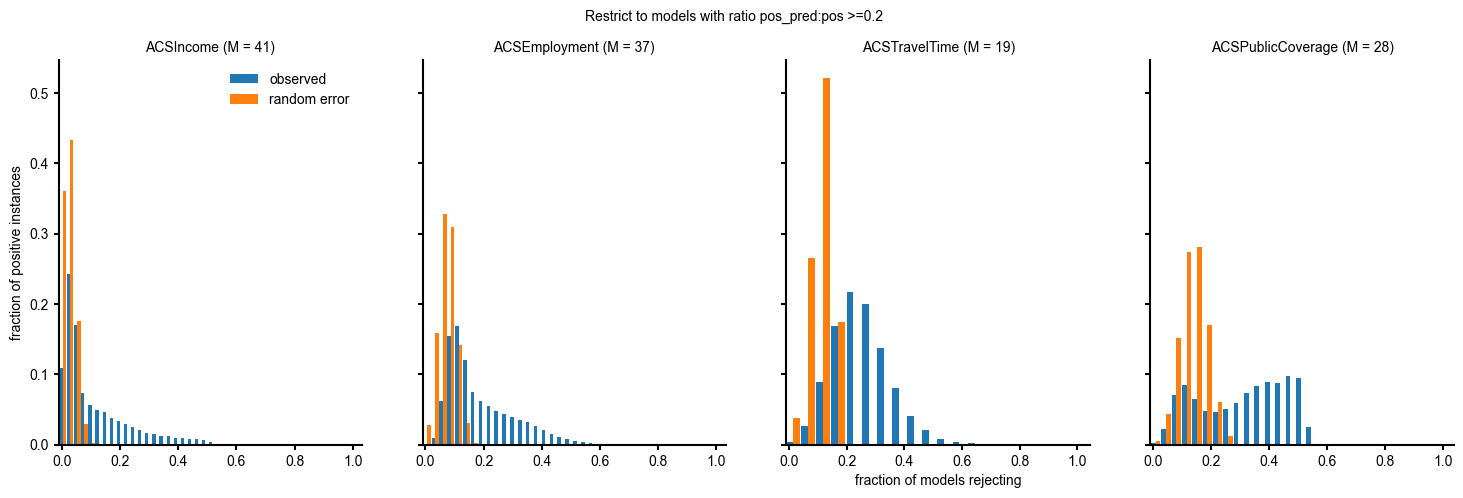

In [ ]:
ratio_threshold = 0.2

pospred2pos_above_thresh = {
    task: {
        k: 1 - min(1.0, v)
        for k, v in pos_pred_to_pos_ratio[task].items()
        if v >= ratio_threshold
    }  # cap at 1 and take counter-"prob"
    for task in TASKS
}
predictions_filtered = {
    task: pred.filter(items=pospred2pos_above_thresh[task].keys())
    for task, pred in predictions.items()
}

plot_model_agreement_all_tasks(
    tasks=TASKS,
    predictions=predictions_filtered,
    baseline_rates=pospred2pos_above_thresh,
    data=data,
    restrict_only_pos_instances=True,
    title=f"Restrict to models with ratio pos_pred:pos >={ratio_threshold}",
    plot_cumulative=False,
    save_path=None,
)

### Fix TPR of model

In [ ]:
# load risk scores
risk_scores = {}
for task in TASKS:
    task_df = df[(df["task"] == task)]
    risk_scores_per_task = []
    # available models
    models = task_df["model"].unique().tolist()
    models.sort(key=lambda m: get_model_size_B(m) + int(is_instruction_tuned(m)))

    for m in models:
        data_m = task_df[task_df["model"] == m]
        assert (
            data_m.shape[0] == 1
        ), f"Found {data_m.shape[0]} results for model {m}, expected 1"
        risk_scores_per_task.append(
            load_risk_scores(data_m.iloc[0]["predictions_path"])
        )
    risk_scores[task] = pd.concat(risk_scores_per_task, axis=1)

In [ ]:
# Get decision thresholds to realize TPR close to threshold
tpr_threshold = 0.5
decision_thresholds = {}  # {'model': None, 'threshold': None, 'tpr': None, 'fpr': None}

for task in TASKS:
    y_true = data[task][1]
    decision_thresholds[task] = {}
    for model in risk_scores[task].columns:
        y_pred_proba = risk_scores[task][model]
        fprs, tprs, thresholds = metrics.roc_curve(
            y_true, y_pred_proba, sample_weight=None
        )
        idx = bisect.bisect(
            tprs, x=tpr_threshold
        )  # The return value i is such that all e in a[:i] have e <= x, and all e in a[i:] have e > x. So if x already appears in the list, a.insert(i, x) will insert just after the rightmost x already there.

        # plt.plot(fpr, tpr)
        # plt.xlabel("FPR"); plt.ylabel("TPR")
        # plt.scatter(fpr[idx], tpr[idx], c='red', s=40, zorder=3)
        # plt.show()

        decision_threshold = thresholds[
            idx
        ]  # if tpr[idx] == tpr_threshold else tpr[idx]
        predictions_thresholded = (y_pred_proba >= decision_threshold).astype(int)

        decision_thresholds[task][model] = {
            "threshold": decision_threshold,
            "tpr": tprs[idx],
            "fpr": fprs[idx],
        }

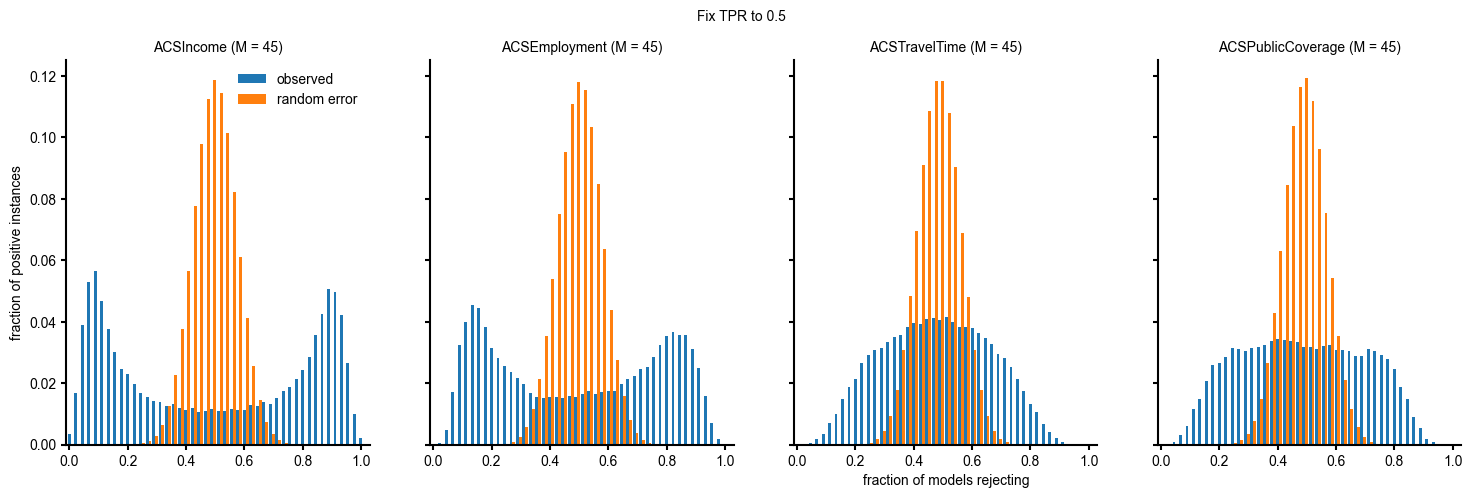

In [ ]:
fn_rates_below_thresh = {
    task: {
        k: 1.0 - v["tpr"]
        for k, v in decision_thresholds[task].items()
        if v["tpr"] >= tpr_threshold
    }
    for task in TASKS
}
decision_thresholds_df = {
    task: pd.DataFrame.from_dict(decision_thresholds[task]) for task in TASKS
}
predictions_fixed_tpr = {
    task: scores.apply(
        lambda row: row >= decision_thresholds_df[task].loc["threshold"], axis=1
    ).astype(
        int
    )  # pred.filter(items=tp_rates_above_thresh[task].keys())
    for task, scores in risk_scores.items()
}


plot_model_agreement_all_tasks(
    tasks=TASKS,
    predictions=predictions_fixed_tpr,
    baseline_rates=fn_rates_below_thresh,
    data=data,
    restrict_only_pos_instances=True,
    title=f"Fix TPR to {tpr_threshold}",
    plot_cumulative=False,
    save_path=None,
)

#### all models

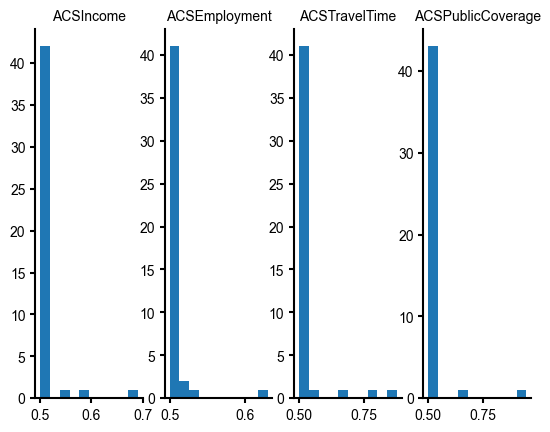

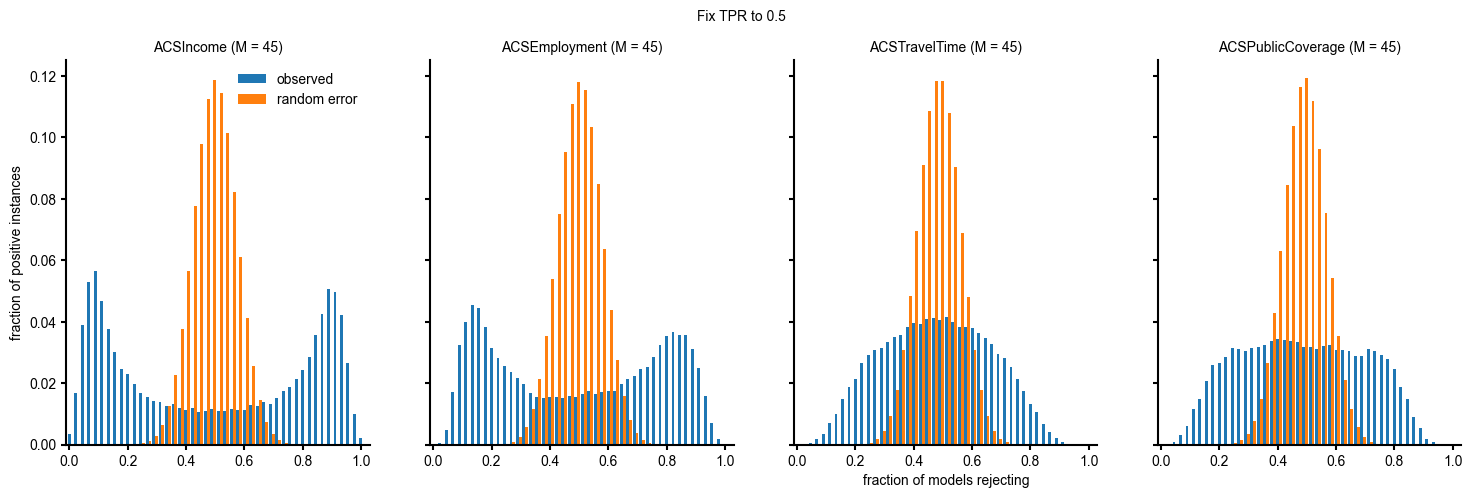

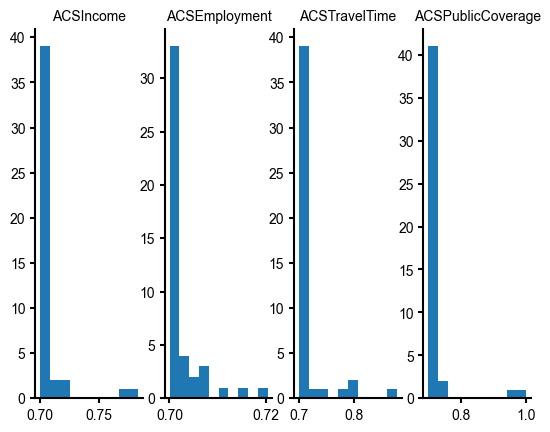

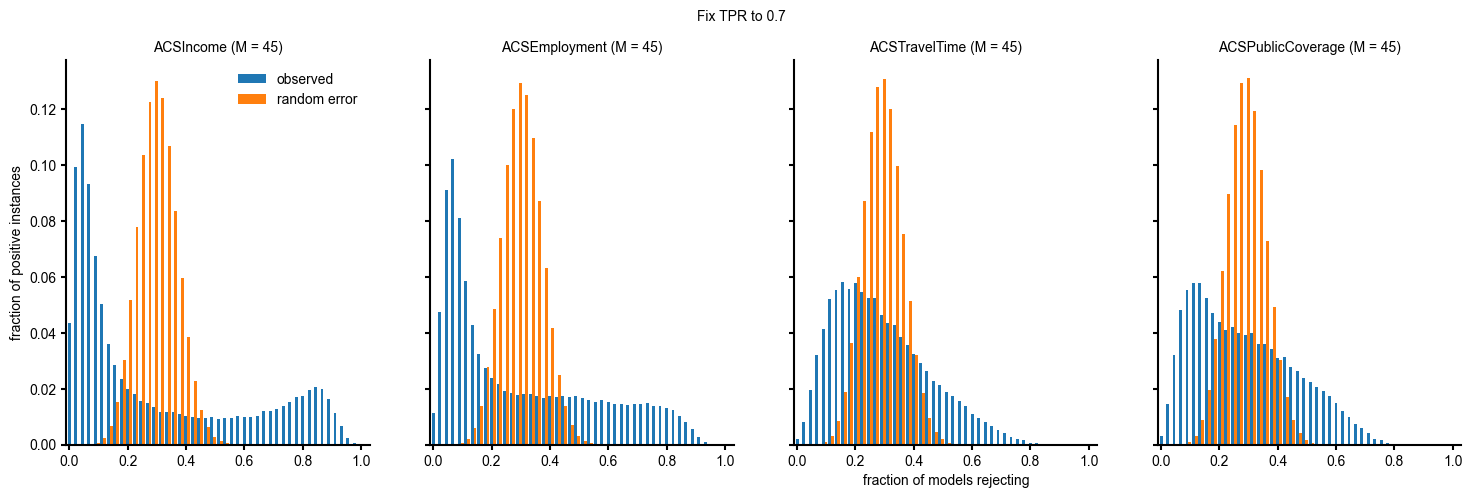

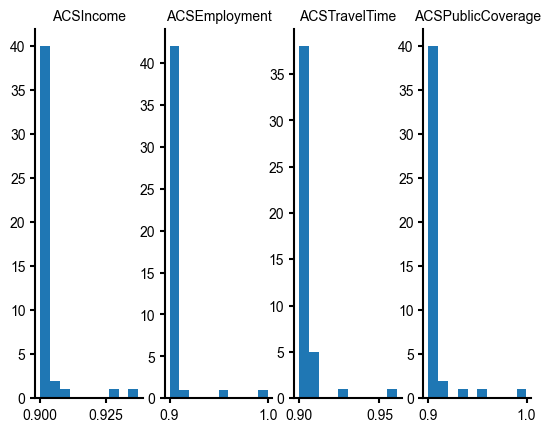

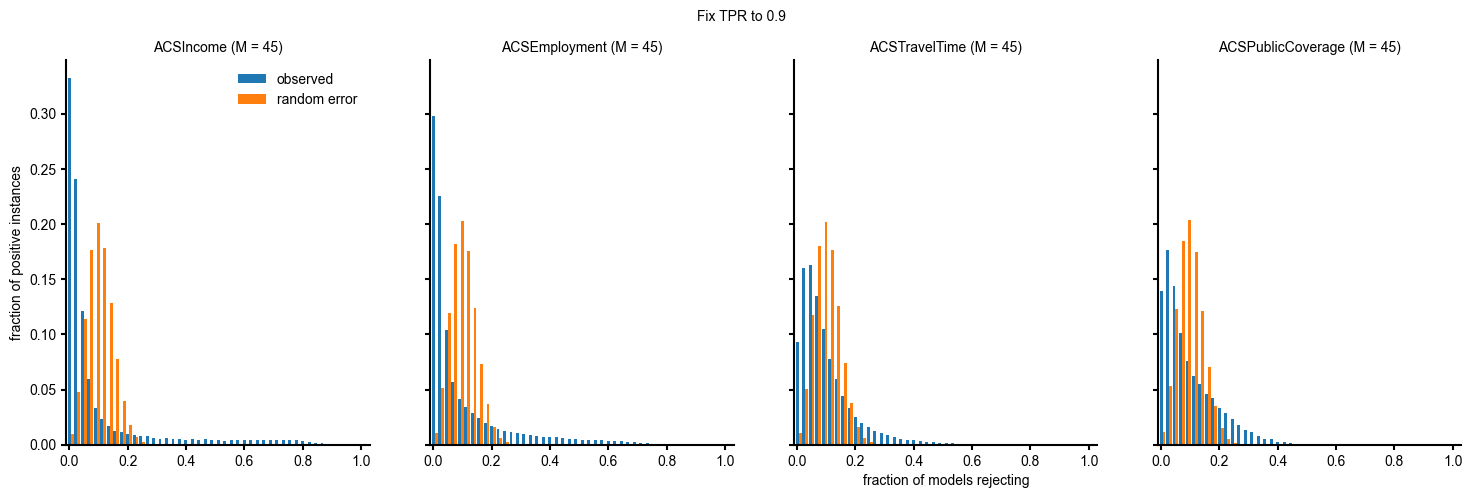

In [ ]:
# Get decision thresholds to realize TPR close to threshold
decision_thresholds = {}
for tpr_threshold in [0.5, 0.7, 0.9]:
    decision_thresholds[tpr_threshold] = (
        {}
    )  # {'model': None, 'threshold': None, 'tpr': None, 'fpr': None}

    for task in TASKS:
        y_true = data[task][1]
        decision_thresholds[tpr_threshold][task] = {}
        for model in risk_scores[task].columns:
            y_pred_proba = risk_scores[task][model]
            fprs, tprs, thresholds = metrics.roc_curve(
                y_true, y_pred_proba, sample_weight=None
            )
            idx = bisect.bisect(
                tprs, x=tpr_threshold
            )  # The return value i is such that all e in a[:i] have e <= x, and all e in a[i:] have e > x. So if x already appears in the list, a.insert(i, x) will insert just after the rightmost x already there.

            # plt.plot(fpr, tpr)
            # plt.xlabel("FPR"); plt.ylabel("TPR")
            # plt.scatter(fpr[idx], tpr[idx], c='red', s=40, zorder=3)
            # plt.show()

            decision_threshold = thresholds[
                idx
            ]  # if tpr[idx] == tpr_threshold else tpr[idx]
            predictions_thresholded = (y_pred_proba >= decision_threshold).astype(int)

            decision_thresholds[tpr_threshold][task][model] = {
                "threshold": decision_threshold,
                "tpr": tprs[idx],
                "fpr": fprs[idx],
            }

    fn_rates_below_thresh = {
        task: {
            k: 1.0 - v["tpr"]
            for k, v in decision_thresholds[tpr_threshold][task].items()
            if v["tpr"] >= tpr_threshold
        }
        for task in TASKS
    }
    decision_thresholds_df = {
        task: pd.DataFrame.from_dict(decision_thresholds[tpr_threshold][task])
        for task in TASKS
    }
    predictions_fixed_tpr = {
        task: scores.apply(
            lambda row: row >= decision_thresholds_df[task].loc["threshold"], axis=1
        ).astype(
            int
        )  # pred.filter(items=tp_rates_above_thresh[task].keys())
        for task, scores in risk_scores.items()
    }

    fig, axs = plt.subplots(1, len(TASKS))
    for i, t in enumerate(TASKS):
        axs[i].hist(decision_thresholds_df[t].loc["tpr"].values)
        axs[i].set_title(t)

    plot_model_agreement_all_tasks(
        tasks=TASKS,
        predictions=predictions_fixed_tpr,
        baseline_rates=fn_rates_below_thresh,
        data=data,
        restrict_only_pos_instances=True,
        title=f"Fix TPR to {tpr_threshold}",
        plot_cumulative=False,
        save_path=FIGURES_ROOT_DIR
        / f"same_prompt_recourse_tpr{str(tpr_threshold).replace('.','_')}.png",
    )

(array([41.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.]),
 array([0.70000883, 0.72997851, 0.75994819, 0.78991787, 0.81988755,
        0.84985723, 0.87982691, 0.90979659, 0.93976627, 0.96973595,
        0.99970563]),
 <BarContainer object of 10 artists>)

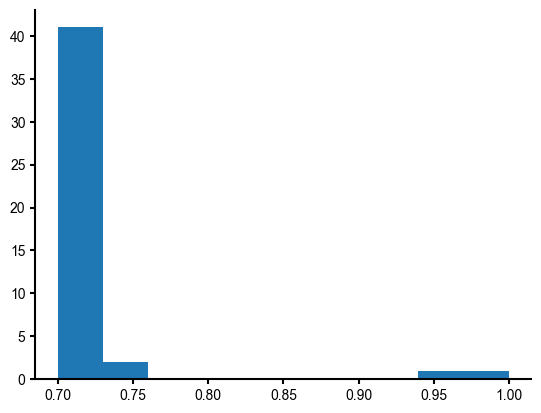

In [ ]:
plt.hist(
    pd.DataFrame.from_dict(decision_thresholds[0.7]["ACSPublicCoverage"])
    .loc["tpr"]
    .values
)

#### For different model families

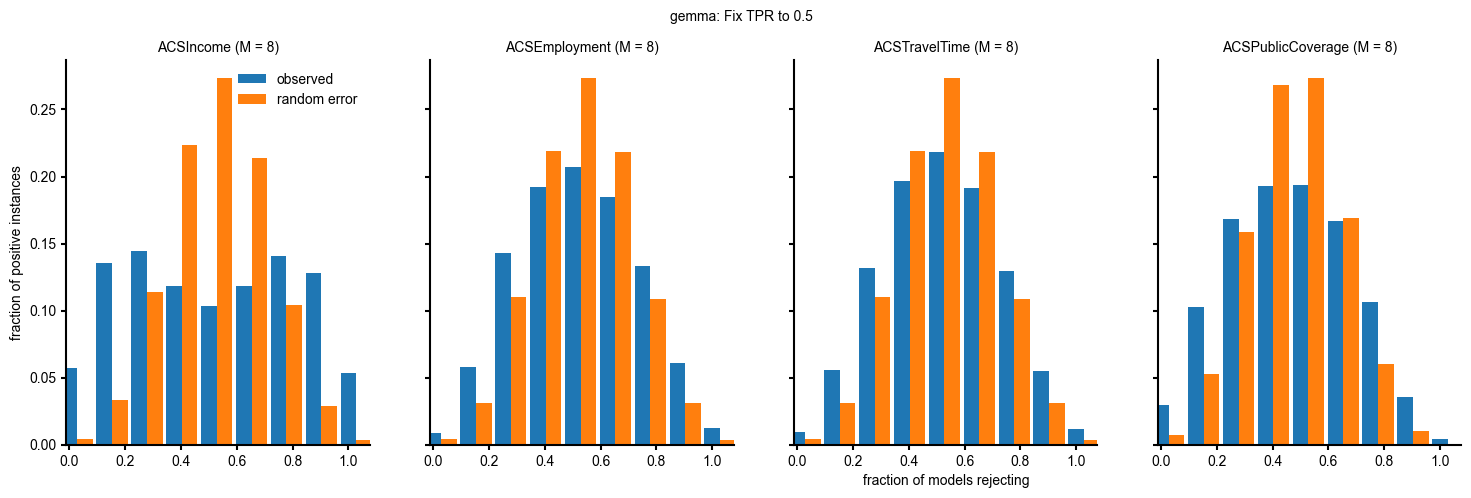

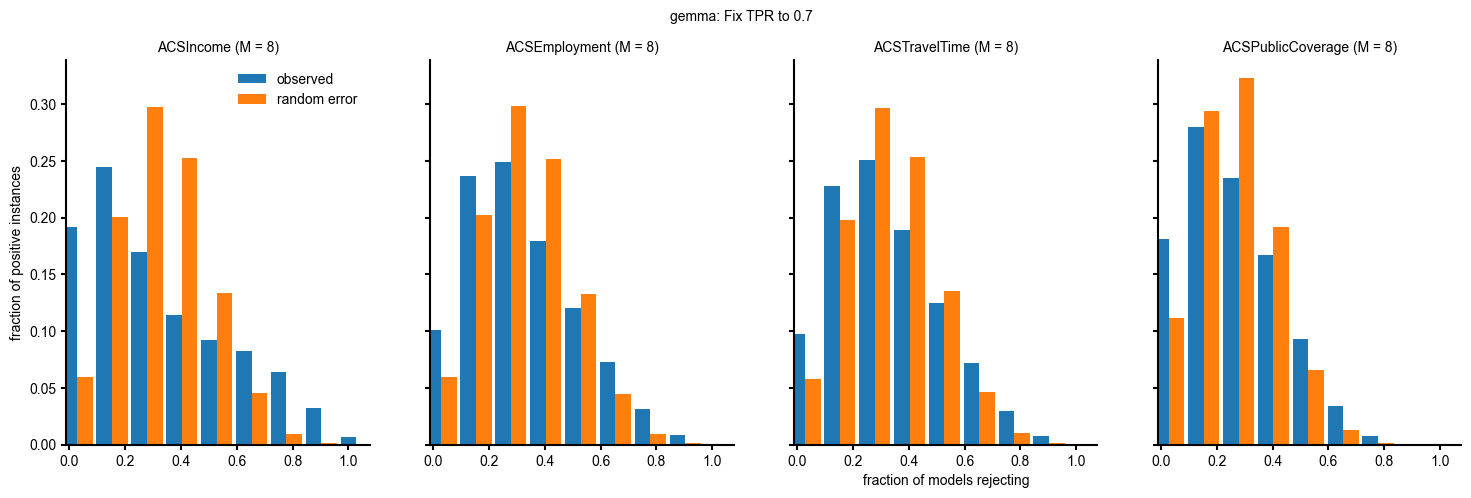

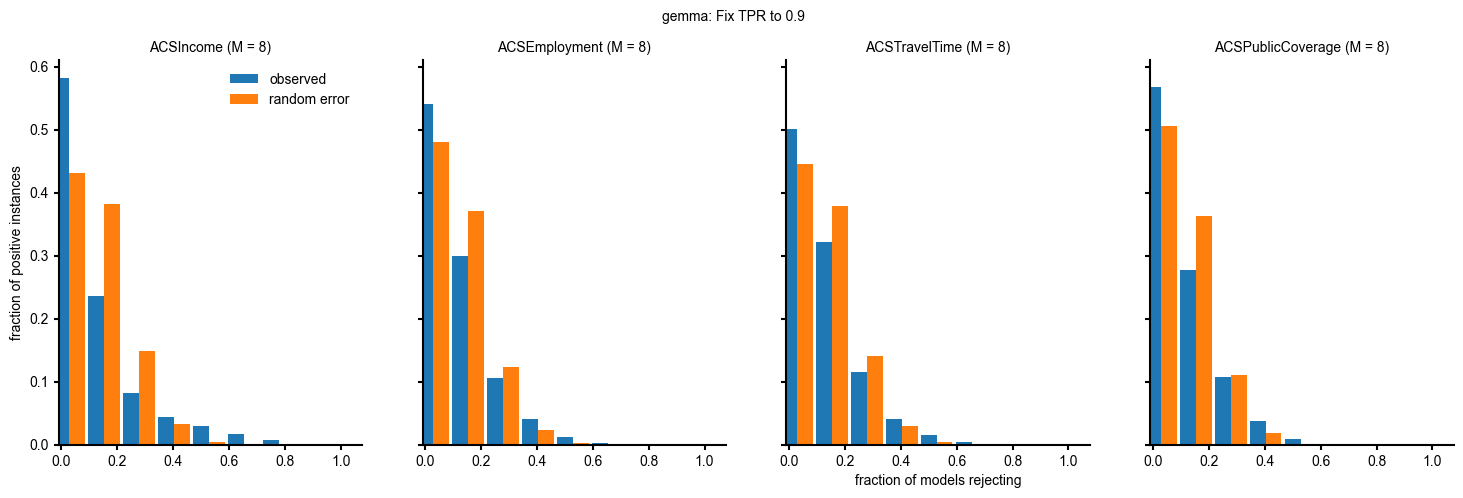

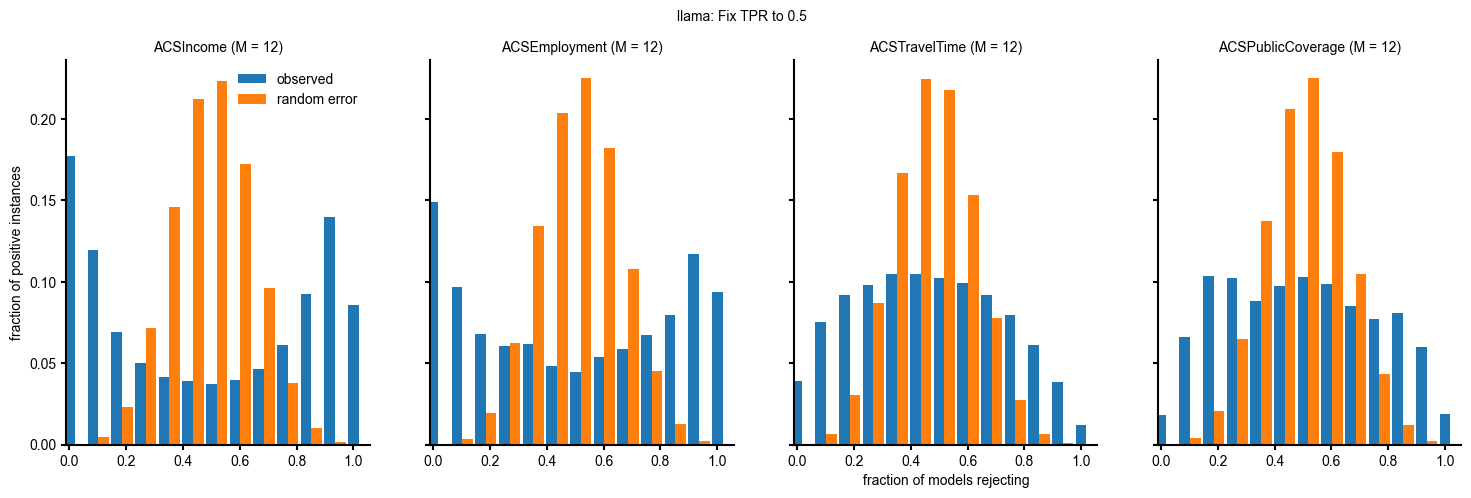

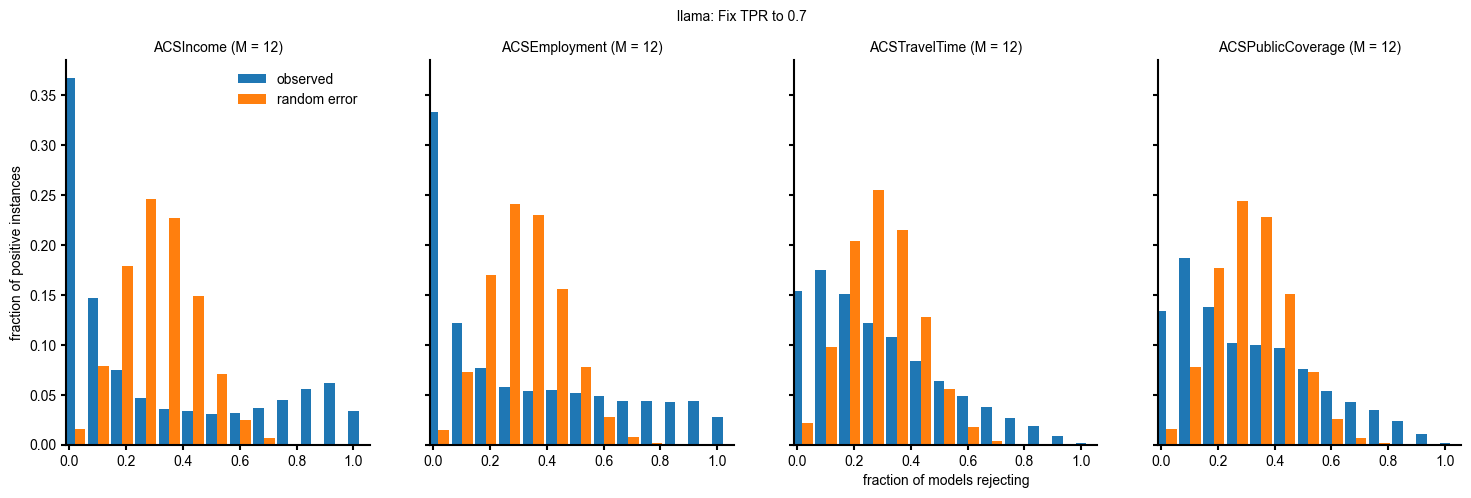

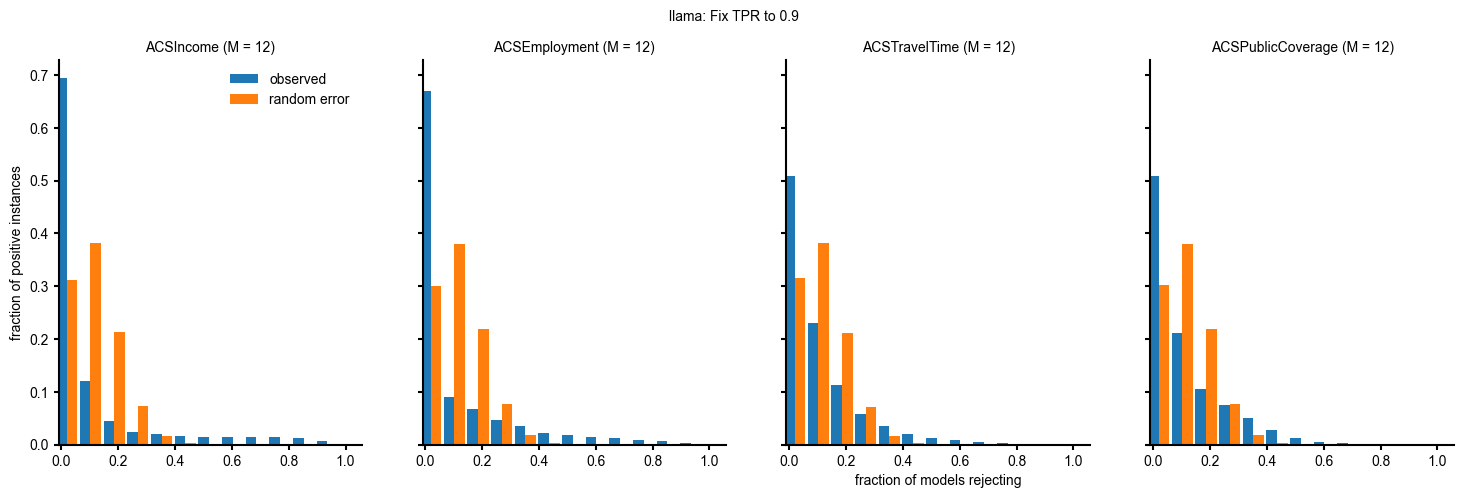

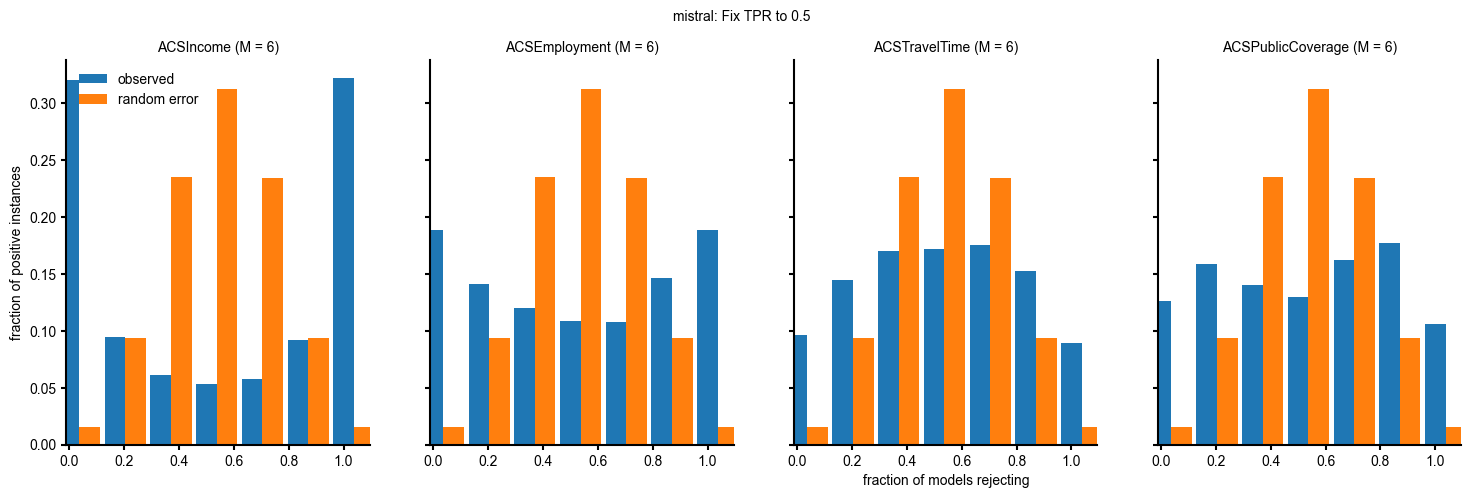

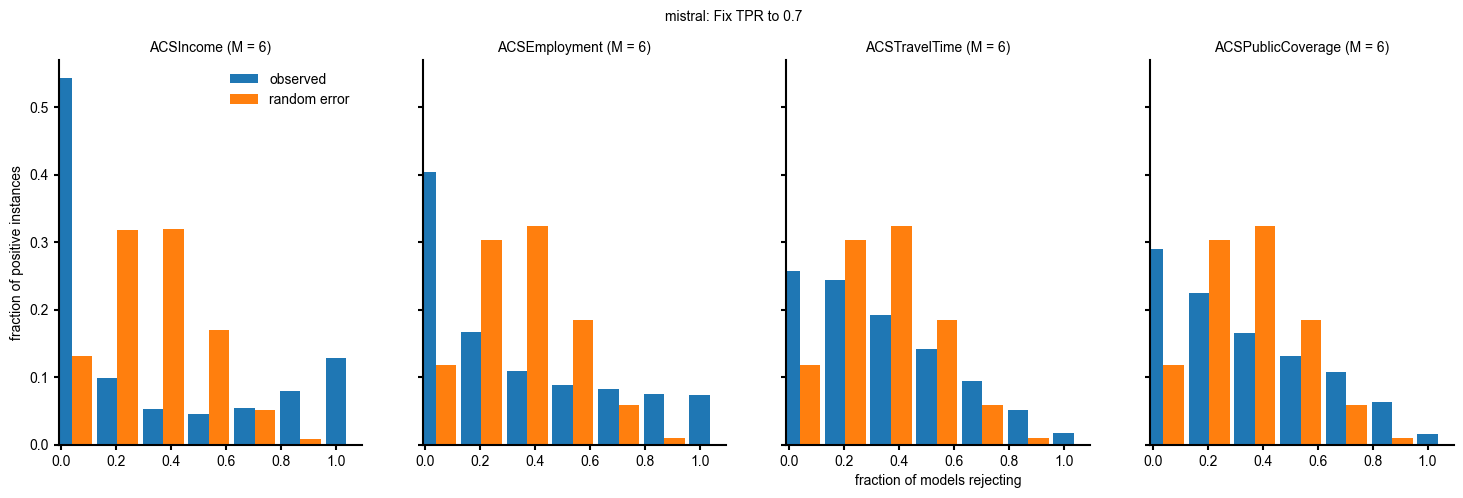

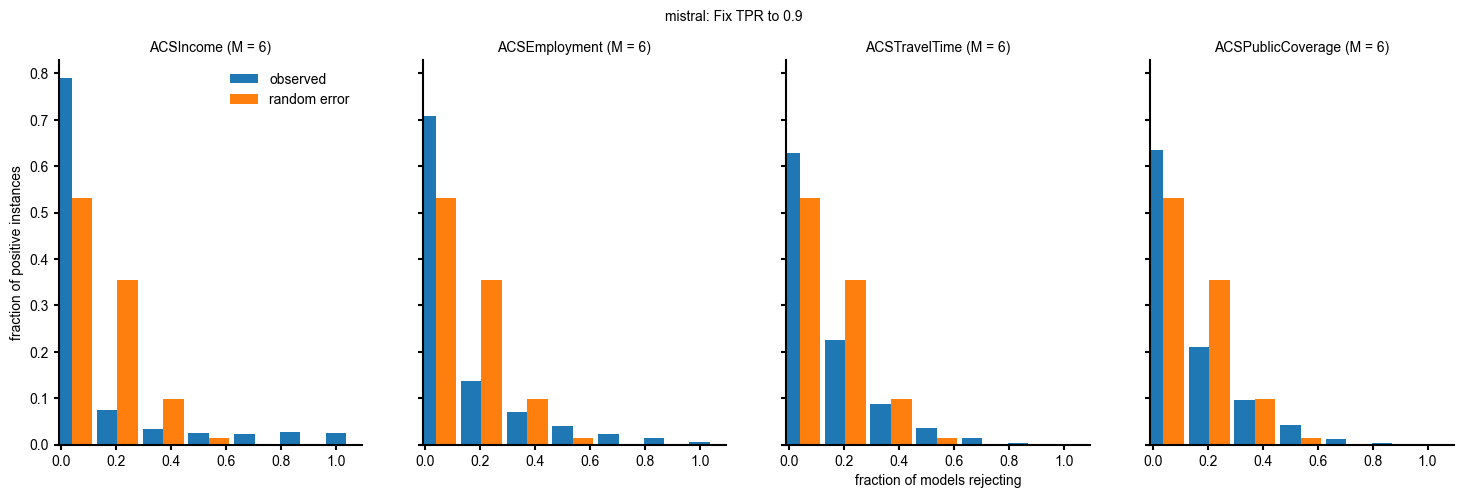

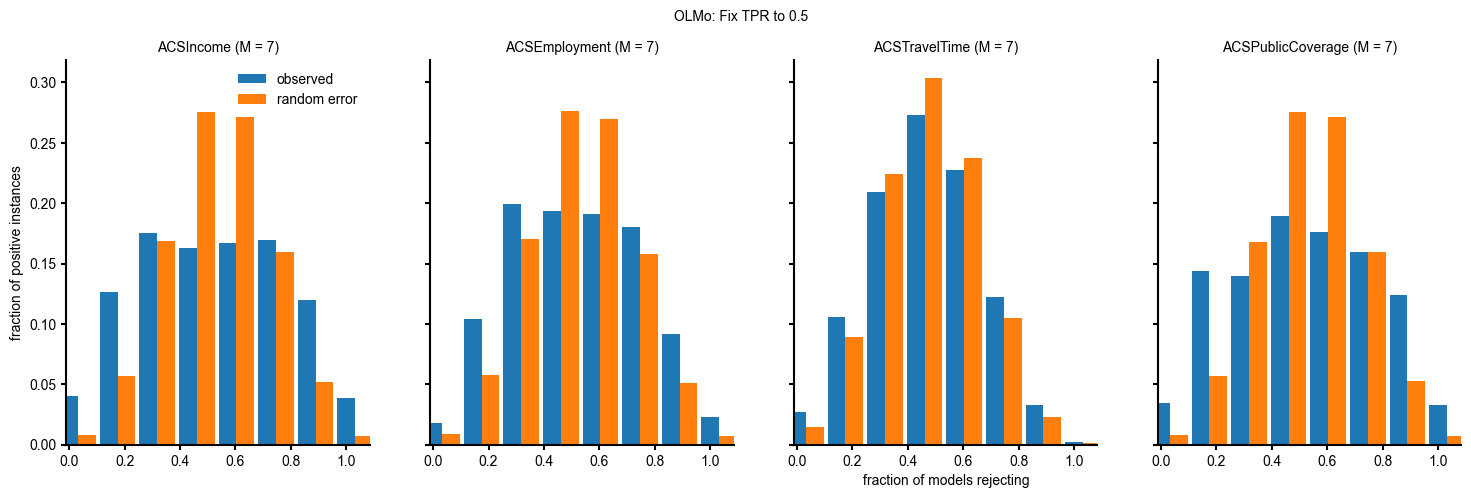

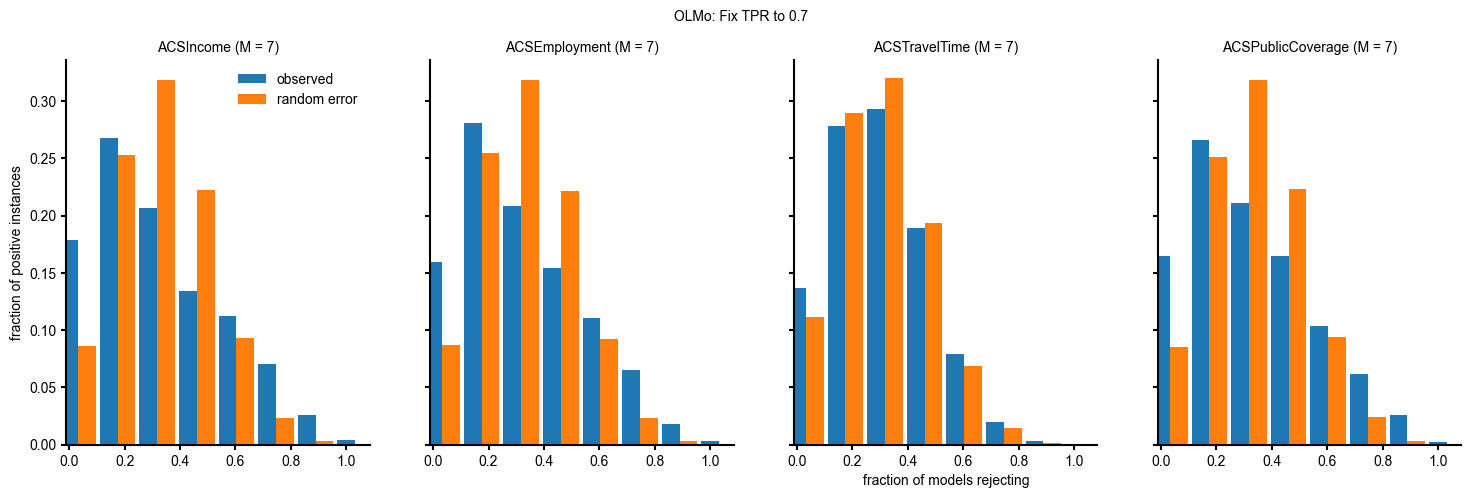

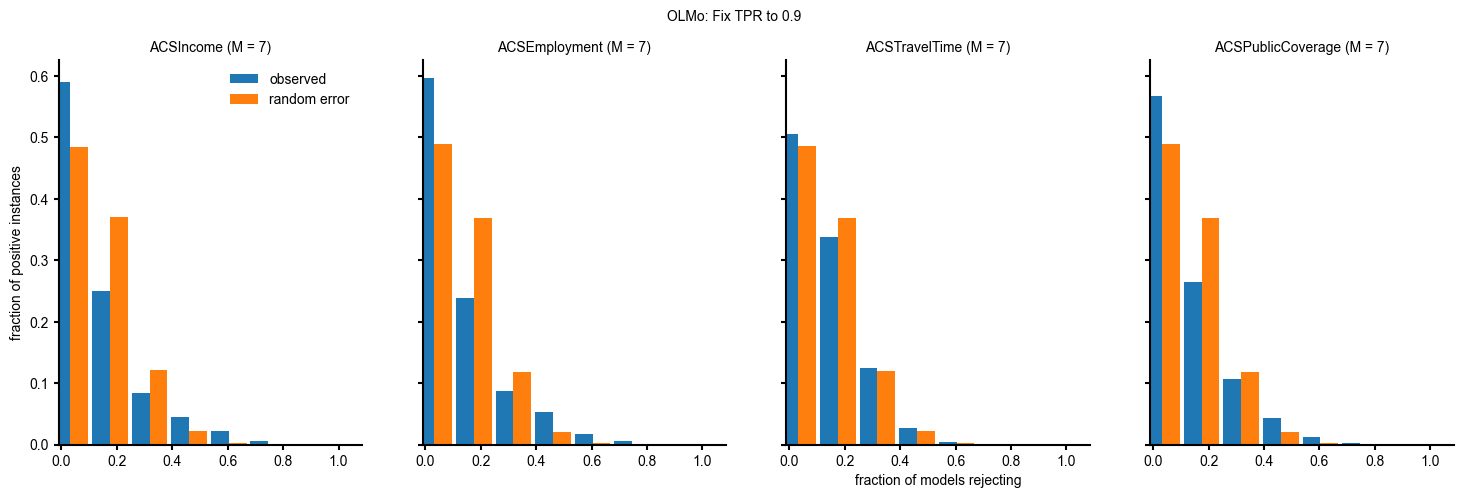

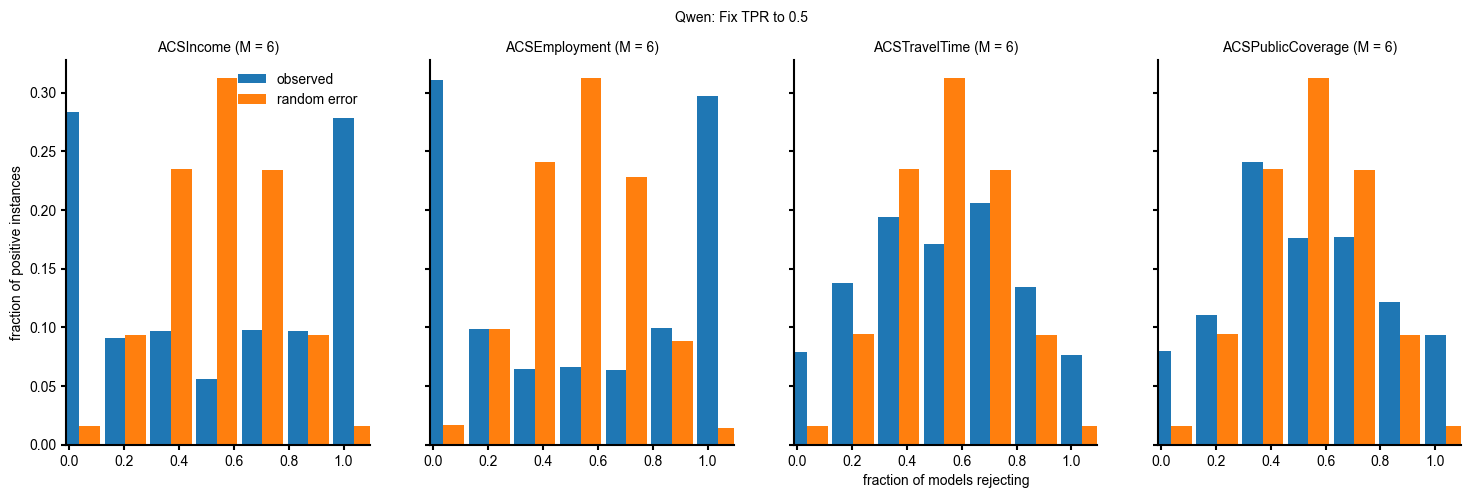

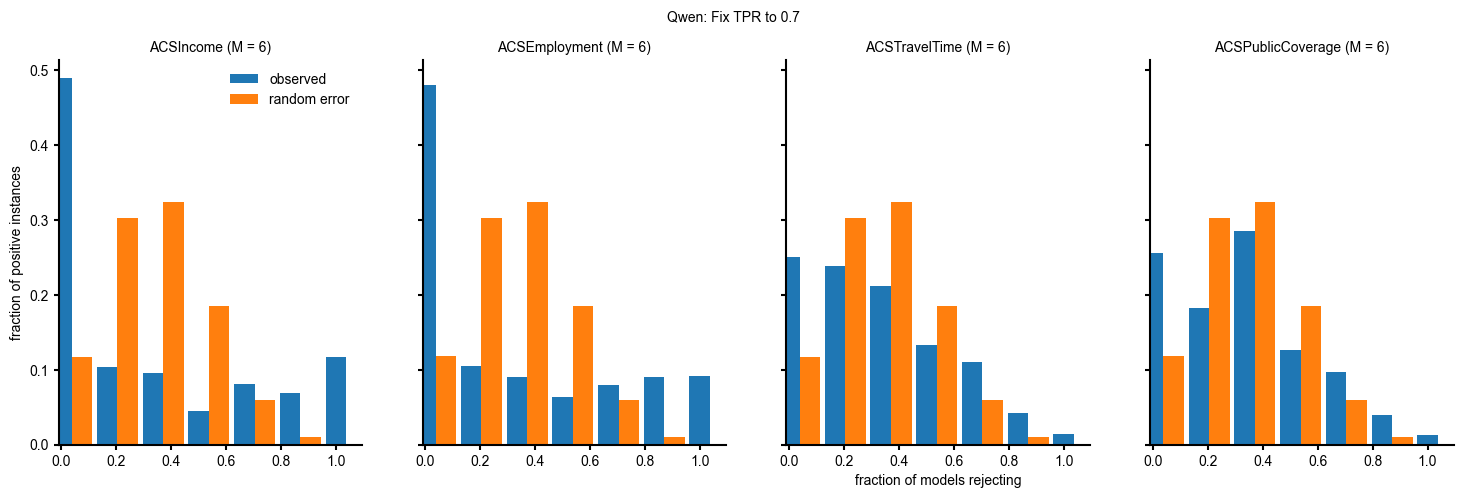

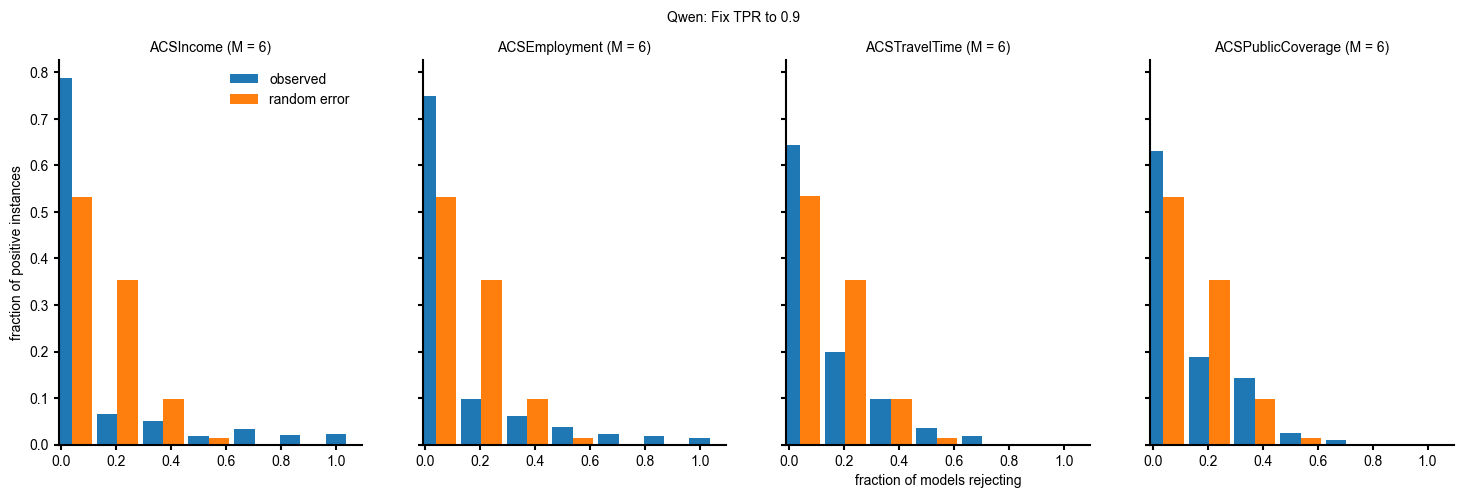

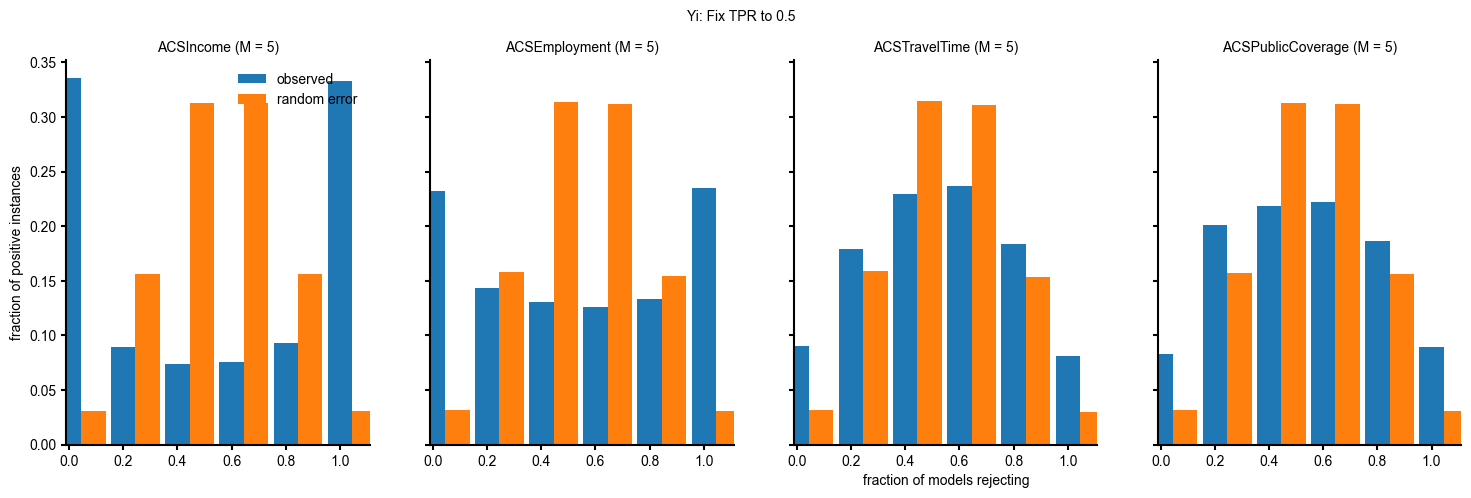

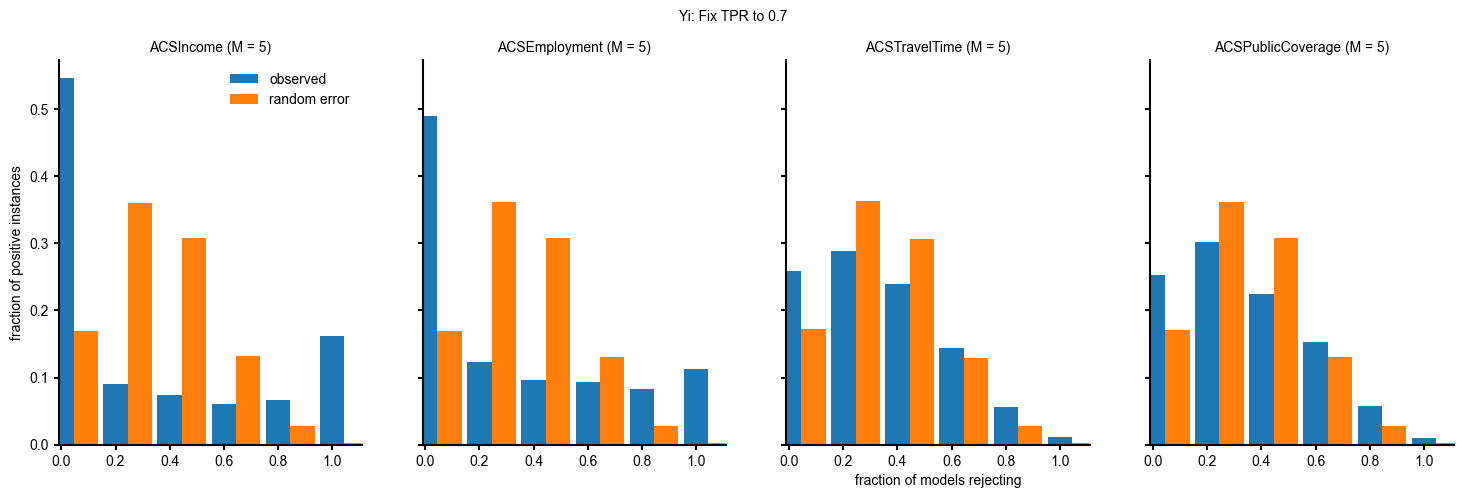

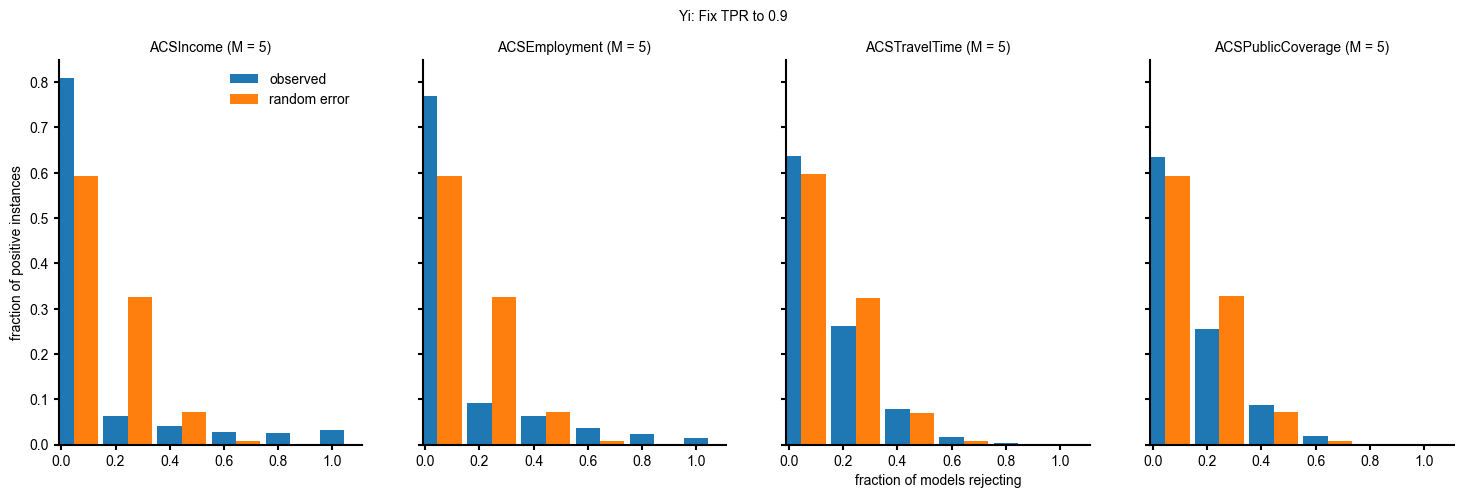

In [ ]:
for model_family in ["gemma", "llama", "mistral", "OLMo", "Qwen", "Yi"]:
    # Get decision thresholds to realize TPR close to threshold
    decision_thresholds = {}
    for tpr_threshold in [0.5, 0.7, 0.9]:
        decision_thresholds[tpr_threshold] = (
            {}
        )  # {'model': None, 'threshold': None, 'tpr': None, 'fpr': None}

        for task in TASKS:
            y_true = data[task][1]
            decision_thresholds[tpr_threshold][task] = {}
            for model in risk_scores[task].filter(like=model_family).columns:
                y_pred_proba = risk_scores[task][model]
                fprs, tprs, thresholds = metrics.roc_curve(
                    y_true, y_pred_proba, sample_weight=None
                )
                idx = bisect.bisect(
                    tprs, x=tpr_threshold
                )  # The return value i is such that all e in a[:i] have e <= x, and all e in a[i:] have e > x. So if x already appears in the list, a.insert(i, x) will insert just after the rightmost x already there.

                # plt.plot(fpr, tpr)
                # plt.xlabel("FPR"); plt.ylabel("TPR")
                # plt.scatter(fpr[idx], tpr[idx], c='red', s=40, zorder=3)
                # plt.show()

                decision_threshold = thresholds[
                    idx
                ]  # if tpr[idx] == tpr_threshold else tpr[idx]
                predictions_thresholded = (y_pred_proba >= decision_threshold).astype(
                    int
                )

                decision_thresholds[tpr_threshold][task][model] = {
                    "threshold": decision_threshold,
                    "tpr": tprs[idx],
                    "fpr": fprs[idx],
                }

        fn_rates_below_thresh = {
            task: {
                k: 1.0 - v["tpr"]
                for k, v in decision_thresholds[tpr_threshold][task].items()
                if v["tpr"] >= tpr_threshold
            }
            for task in TASKS
        }
        decision_thresholds_df = {
            task: pd.DataFrame.from_dict(decision_thresholds[tpr_threshold][task])
            for task in TASKS
        }
        predictions_fixed_tpr = {
            task: scores.filter(like=model_family)
            .apply(
                lambda row: row >= decision_thresholds_df[task].loc["threshold"], axis=1
            )
            .astype(int)  # pred.filter(items=tp_rates_above_thresh[task].keys())
            for task, scores in risk_scores.items()
        }

        plot_model_agreement_all_tasks(
            tasks=TASKS,
            predictions=predictions_fixed_tpr,
            baseline_rates=fn_rates_below_thresh,
            data=data,
            restrict_only_pos_instances=True,
            title=f"{model_family}: Fix TPR to {tpr_threshold}",
            plot_cumulative=False,
            save_path=FIGURES_ROOT_DIR
            / f"same_prompt_recourse_tpr{str(tpr_threshold).replace('.','_')}_family_{model_family}.png",
        )

#### For top-k models

In [ ]:
topk = 10

# Get decision thresholds to realize TPR close to threshold
decision_thresholds = {}
for tpr_threshold in [0.5, 0.7, 0.9]:
    decision_thresholds[tpr_threshold] = (
        {}
    )  # {'model': None, 'threshold': None, 'tpr': None, 'fpr': None}

    for task in TASKS:
        y_true = data[task][1]
        decision_thresholds[tpr_threshold][task] = {}
        sorted_models = sorted(
            accuracies[task].items(), key=lambda item: item[1], reverse=True
        )
        topk_models = [m for m, _ in sorted_models[:topk]]

        for model in topk_models:
            y_pred_proba = risk_scores[task][model]
            fprs, tprs, thresholds = metrics.roc_curve(
                y_true, y_pred_proba, sample_weight=None
            )
            idx = bisect.bisect(
                tprs, x=tpr_threshold
            )  # The return value i is such that all e in a[:i] have e <= x, and all e in a[i:] have e > x. So if x already appears in the list, a.insert(i, x) will insert just after the rightmost x already there.

            # plt.plot(fpr, tpr)
            # plt.xlabel("FPR"); plt.ylabel("TPR")
            # plt.scatter(fpr[idx], tpr[idx], c='red', s=40, zorder=3)
            # plt.show()

            decision_threshold = thresholds[
                idx
            ]  # if tpr[idx] == tpr_threshold else tpr[idx]
            predictions_thresholded = (y_pred_proba >= decision_threshold).astype(int)

            decision_thresholds[tpr_threshold][task][model] = {
                "threshold": decision_threshold,
                "tpr": tprs[idx],
                "fpr": fprs[idx],
            }

    fn_rates_below_thresh = {
        task: {
            k: 1.0 - v["tpr"]
            for k, v in decision_thresholds[tpr_threshold][task].items()
            if v["tpr"] >= tpr_threshold
        }
        for task in TASKS
    }
    decision_thresholds_df = {
        task: pd.DataFrame.from_dict(decision_thresholds[tpr_threshold][task])
        for task in TASKS
    }
    predictions_fixed_tpr = {
        task: scores.filter(items=topk_models)
        .apply(lambda row: row >= decision_thresholds_df[task].loc["threshold"], axis=1)
        .astype(int)  # pred.filter(items=tp_rates_above_thresh[task].keys())
        for task, scores in risk_scores.items()
    }

    plot_model_agreement_all_tasks(
        tasks=TASKS,
        predictions=predictions_fixed_tpr,
        baseline_rates=fn_rates_below_thresh,
        data=data,
        restrict_only_pos_instances=True,
        title=f"{model_family}: Fix TPR to {tpr_threshold}",
        plot_cumulative=False,
        save_path=FIGURES_ROOT_DIR
        / f"same_prompt_recourse_tpr{str(tpr_threshold).replace('.','_')}_family_{model_family}.png",
    )

ValueError: Can only compare identically-labeled Series objects

### No Recourse as a function of M (model set size)

In [ ]:
topk = 10
models_above_baseline = {}
topk_models = {}
baselines_above_baseline = {}
observed_no_recourse = {}
expected_no_recourse = {}
subsets_all = {}

for task in TASKS[:2] + TASKS[-2:]:
    baseline_acc = baseline_evals[task]["Constant"]["accuracy"]
    models_above_baseline[task] = [
        model
        for model in predictions[task].keys().tolist()
        if truncate(accuracies[task][model], 6) > truncate(baseline_acc, 6)
    ]
    topk_models[task] = sorted(
        models_above_baseline[task], key=lambda m: accuracies[task][m], reverse=True
    )[:topk]
    # baselines_above_baseline[task] = [
    #     baseline
    #     for baseline in list(baselines.keys())
    #     if baseline_evals[task][baseline]["accuracy"] > baseline_acc
    # ]
    num_models = len(models_above_baseline[task])
    print(task, num_models)  # , models_above_baseline[task])
predictions_above_baseline = {
    key: val.filter(items=models_above_baseline[key])
    for key, val in predictions.items()
}


# for task in TASKS[:2]+TASKS[-2:]:
#     print(task)
#     true_labels = data[task][1]
#     M = topk #len(models_above_baseline[task])
#     num_positives = (true_labels == 1).sum()
#     predictions_above_baseline_pos_instances = predictions_above_baseline[task][
#         true_labels == 1
#     ]

#     subsets_all[task] = {}
#     observed_no_recourse[task] = {}
#     expected_no_recourse[task] = {}

#     for subsetsize in range(1, 6): #M + 1):
#         # get all possible subsets
#         subsets = list(combinations(topk_models[task], r=subsetsize))
#         subsets_all[task][subsetsize] = subsets
#         print(
#             f"Compute fractions of inidividuals observing no recourse for {int(sp.special.comb(M, subsetsize))} subsets."
#         )
#         observed_no_recourse[task][subsetsize] = [
#             get_observed_k_rejections(
#                 k=subsetsize,
#                 predictions=predictions_above_baseline_pos_instances.filter(
#                     items=subset
#                 ),  ## already filtered to only positive instances
#             )
#             / num_positives
#             for subset in subsets
#         ]
#         expected_no_recourse[task][subsetsize] = [
#             sp.stats.poisson_binom.pmf(
#                 k=subsetsize, p=np.array([fn_rates[task][model] for model in subset])
#             )
#             for subset in subsets
#         ]

ACSIncome 40
ACSEmployment 42
BRFSS_Diabetes 0
BRFSS_Blood_Pressure 36


In [ ]:
[f"{m}    {accuracies['ACSIncome'][m]}" for m in topk_models["ACSIncome"]]

['meta-llama--Meta-Llama-3.3-70B-Instruct    0.7884830279363172',
 'Qwen--Qwen2.5-72B    0.7806668669270052',
 'mistralai--Mistral-Small-24B-Instruct-2501    0.7803664764193452',
 'Qwen--Qwen2.5-72B-Instruct    0.777194352658456',
 'meta-llama--Meta-Llama-3-70B-Instruct    0.7759026734755182',
 'meta-llama--Meta-Llama-3.1-70B-Instruct    0.7742144788224692',
 'meta-llama--Meta-Llama-3.1-70B    0.7679122859717633',
 'meta-llama--Meta-Llama-3-8B-Instruct    0.7672754580955242',
 'Qwen--Qwen2-7B-Instruct    0.7637729047762091',
 'meta-llama--Meta-Llama-3-70B    0.7636407329528387']

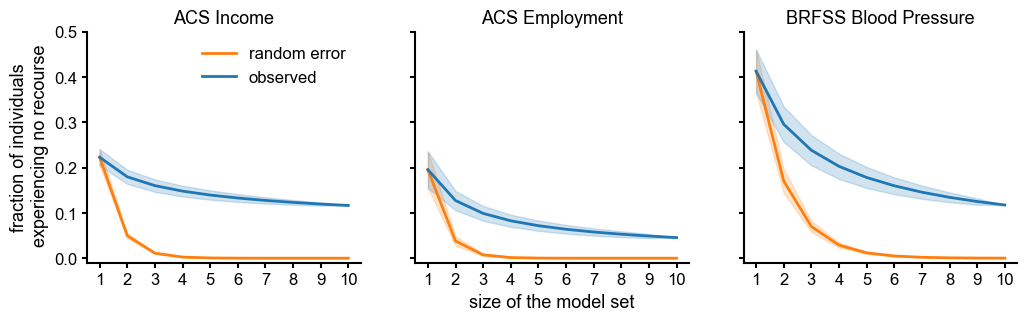

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i, task in enumerate(TASKS[:2] + TASKS[-1:]):
    M = topk  # len(models_above_baseline[task])
    obs_mean = {
        s: np.array(observed_no_recourse[task][s]).mean() for s in range(1, M + 1)
    }
    exp_mean = {
        s: np.array(expected_no_recourse[task][s]).mean() for s in range(1, M + 1)
    }
    obs_std = {
        s: np.array(observed_no_recourse[task][s]).std() for s in range(1, M + 1)
    }
    exp_std = {
        s: np.array(expected_no_recourse[task][s]).std() for s in range(1, M + 1)
    }  # var()/s  standard error
    axs[i].set_ylim(-0.01, 0.5)

    axs[i].set_title(task.replace("ACS", "ACS ").replace("_", " "))
    axs[i].plot(
        np.arange(1, M + 1),
        [exp_mean[s] for s in range(1, M + 1)],
        color="C1",
        label="random error",
    )  # expected based on model FNR
    axs[i].plot(
        np.arange(1, M + 1),
        [obs_mean[s] for s in range(1, M + 1)],
        color="C0",
        label="observed",
    )
    axs[i].fill_between(
        np.arange(1, M + 1),
        [exp_mean[s] + exp_std[s] for s in range(1, M + 1)],
        [exp_mean[s] - exp_std[s] for s in range(1, M + 1)],
        alpha=0.2,
        color="C1",
    )
    axs[i].fill_between(
        np.arange(1, M + 1),
        [obs_mean[s] + obs_std[s] for s in range(1, M + 1)],
        [obs_mean[s] - obs_std[s] for s in range(1, M + 1)],
        alpha=0.2,
        color="C0",
    )

    axs[i].set_xticks(np.arange(1, M + 1))

axs[1].set_xlabel("size of the model set")
axs[0].set_ylabel("fraction of individuals\n experiencing no recourse")
axs[0].legend()

# plt.savefig(
#     "/Users/mgorecki/Documents/2025-04-SAB-meeting/figures/no_recourse.png",
# )

plt.show()

## Plot ROC curves

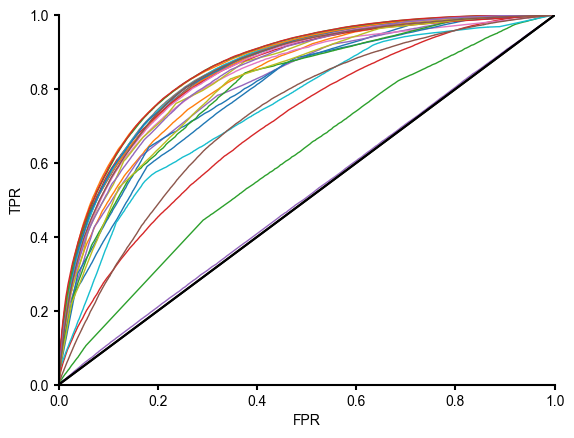

In [ ]:
from sklearn import metrics

MODELS_SUBSET = [
    "meta-llama--Meta-Llama-3-70B",
    "meta-llama--Meta-Llama-3-70B-Instruct",
    "meta-llama--Meta-Llama-3.1-70B",
    "meta-llama--Meta-Llama-3.1-70B-Instruct",
]

models = sorted(df_10shot["model"].unique().tolist(), key=get_model_size_B)

aucs = {}
y_true = data["ACSIncome"][1]
for model in models:  # MODELS_SUBSET: #
    y_pred_proba = risk_scores["ACSIncome"][model].to_numpy()
    fpr, tpr, _ = metrics.roc_curve(y_true, y_pred_proba, sample_weight=None)
    auc = metrics.roc_auc_score(y_true, y_pred_proba)
    aucs[model] = auc
    plt.plot(
        fpr,
        tpr,
        label=f"{prettify_model_name(key_to_model(model))}, auc={auc:.3f}",
        linewidth=1,
    )
# plt.legend(loc=4)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.plot([(0, 0), (1, 1)], color="black")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

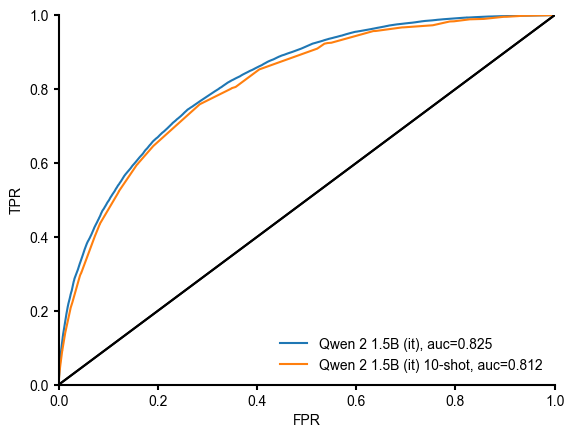

In [ ]:
y_true = data["ACSIncome"][1]
model = "Qwen--Qwen2-1.5B-Instruct"  #'meta-llama--Meta-Llama-3-8B' #'mistralai--Mixtral-8x7B-Instruct-v0.1' #
y_pred_proba = risk_scores["ACSIncome"][model].to_numpy()
y_10shot_pred_proba = risk_scores_10shot["ACSIncome"][model].to_numpy()
fpr, tpr, _ = metrics.roc_curve(y_true, y_pred_proba, sample_weight=None)
fpr_10shot, tpr_10shot, _ = metrics.roc_curve(
    y_true, y_10shot_pred_proba, sample_weight=None
)
auc = metrics.roc_auc_score(y_true, y_pred_proba)
auc_10shot = metrics.roc_auc_score(y_true, y_10shot_pred_proba)
plt.plot(fpr, tpr, label=f"{prettify_model_name(key_to_model(model))}, auc={auc:.3f}")
plt.plot(
    fpr_10shot,
    tpr_10shot,
    label=f"{prettify_model_name(key_to_model(model))} 10-shot, auc={auc_10shot:.3f}",
)
# plt.legend(loc=4)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.plot([(0, 0), (1, 1)], color="black")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

For most models, that I tested, the ROC curve and AUC do not vary a lot. At the same time, the accuracy increases significantly for some models: 

In [ ]:
accuracies["ACSIncome"]["Qwen--Qwen2-1.5B-Instruct"], accuracies_10shot["ACSIncome"][
    "Qwen--Qwen2-1.5B-Instruct"
]

(0.3687233403424452, 0.7313968158606188)

In [ ]:
(
    (risk_scores_10shot["ACSIncome"][model] >= 0.5304518664047151)
    == data["ACSIncome"][1]
).mean()
# 0.5649264879314412 after fitting on 10_000 training samples
# 0.8518804077786345 on test data

0.7491198558125564

In [ ]:
0.74145_98978672274  # at argmin -- larger acc
0.74145_38900570742  # at argmin - 1


# 10 shot
0.7313968158606188  # at argmin
metrics.confusion_matrix(
    data["ACSIncome"][1], risk_scores_10shot["ACSIncome"][model] >= 0.5
)[
    [0, 1], [1, 0]
].sum()  # 44709
0.7491198558125564  # at argmin - 1 -- larger acc
metrics.confusion_matrix(
    data["ACSIncome"][1], risk_scores_10shot["ACSIncome"][model] >= 0.5304518664047151
)[
    [0, 1], [1, 0]
].sum()  # 41759

In [ ]:
neg, pos = metrics.confusion_matrix(
    data["ACSIncome"][1], risk_scores_10shot["ACSIncome"][model] >= 0.5
).sum(axis=1)
neg, pos

(105217, 61233)

In [ ]:
(tn, fp), (fn, tp) = metrics.confusion_matrix(
    data["ACSIncome"][1], risk_scores_10shot["ACSIncome"][model] >= 0.5
)
fp / (tn + fp) + fn / (tp + fn), fp, fn, fn + fp

(0.5256936362110276, 29948, 14761, 44709)

In [ ]:
(tn, fp), (fn, tp) = metrics.confusion_matrix(
    data["ACSIncome"][1], risk_scores_10shot["ACSIncome"][model] >= 0.5304518664047151
)
fp / (tn + fp) + fn / (tp + fn), fp, fn, fn + fp

(0.5449530755306622, 20070, 21689, 41759)

In [ ]:
fpr, tpr, thresholds = metrics.roc_curve(
    data["ACSIncome"][1], risk_scores_10shot["ACSIncome"][model]
)

# Compute the cost of each threshold
costs = fpr + (1 - tpr)

# Get the threshold that minimizes the cost
best_threshold = thresholds[np.argmin(costs)]
best_threshold

0.5

In [ ]:
thresholds[np.argmin(costs)]

0.5

In [ ]:
thresholds[costs.argmin() - 1]

0.5304518664047151

This suggests, that the 10-shot model is just better calibrated? But signal does not significantly improve?

In [ ]:
risk_scores["ACSIncome"][
    "Qwen--Qwen2-1.5B-Instruct"
]  # risk_scores_10shot["ACSIncome"]['Qwen--Qwen2-1.5B-Instruct']

238351     0.651422
2995677    0.622606
2360043    0.943362
1924596    0.817487
2803585    0.817557
             ...   
43637      0.867094
2494279    0.679207
2989522    0.817562
688458     0.924091
1778641    0.754922
Name: Qwen--Qwen2-1.5B-Instruct, Length: 166450, dtype: float64

Text(0.5, 1.0, 'Risk Scores 0-shot vs. 10-shot\nmodel: Qwen 2 1.5B (it)')

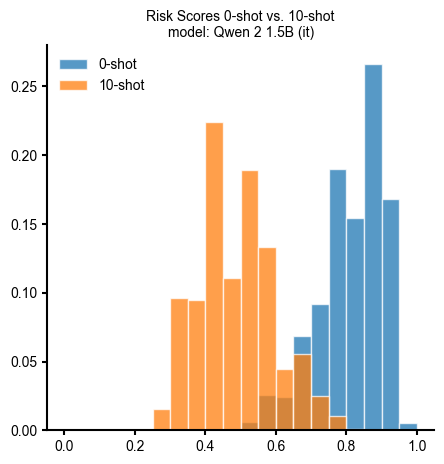

In [ ]:
N = risk_scores["ACSIncome"][model].shape[0]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ys, xs, _ = ax.hist(
    risk_scores["ACSIncome"]["Qwen--Qwen2-1.5B-Instruct"],
    weights=np.zeros((N,)) + 1.0 / N,
    alpha=0.75,
    label="0-shot",
    bins=np.arange(0, 1.01, 0.05),
    edgecolor="w",
    linewidth=1,
)
ys, xs, _ = ax.hist(
    risk_scores_10shot["ACSIncome"]["Qwen--Qwen2-1.5B-Instruct"],
    weights=np.zeros((N,)) + 1.0 / N,
    alpha=0.75,
    label="10-shot",
    bins=np.arange(0, 1.01, 0.05),
    edgecolor="w",
    linewidth=1,
)
ax.legend()
ax.set_title(
    f"Risk Scores 0-shot vs. 10-shot\nmodel: {prettify_model_name(key_to_model(model))}"
)

In [ ]:
from folktexts.evaluation import compute_best_threshold

logging.warning("Threshold computed on TEST data")
compute_best_threshold(
    data["ACSIncome"][1], risk_scores["ACSIncome"][model]
)  # -- not possible here because risk scores on train data are not known

0.8518804077786345

What is the expected size of the model set, that ranks a positive instance higher than a negative one? 

In [ ]:
def score_comparisons(y_true: pd.Series, y_pred: pd.Series):
    idx_neg = y_true[y_true == 0].index.tolist()
    idx_pos = y_true[y_true == 1].index.tolist()

    # get random indices (pos, neg)
    num_draws = 100000
    rnd_neg_idx = np.random.choice(idx_neg, size=(num_draws,))
    rnd_pos_idx = np.random.choice(idx_pos, size=(num_draws,))

    y_pred_pos = y_pred.loc[rnd_pos_idx]
    y_pred_neg = y_pred.loc[rnd_neg_idx]

    return (
        (y_pred_pos.reset_index(drop=True) > y_pred_neg.reset_index(drop=True))
        .astype(int)
        .to_numpy()
    )

In [ ]:
expected_cardinality = (
    np.array(
        [
            score_comparisons(y_true, risk_scores["ACSIncome"][model])
            for model in MODELS_SUBSET
        ]
    )
    .sum(axis=0)
    .mean(axis=0)
)
expected_cardinality / len(MODELS_SUBSET)

0.8509825

In [ ]:
aucs[MODELS_SUBSET[0]]

0.8539093789357155